# Premier League Market Value Predictor


## Project Overview

This project aims to develop a machine learning model capable of estimating the market value of Premier League football players based on player characteristics and performance statistics.

## Research Question

**Can a player's age, position, playing time, and on-pitch performance be used to estimate their market value?**

## Objectives

1. Collect relevant Premier League player-performance and market-value data.
2. Clean and combine the datasets.
3. Explore the relationship between player performance and market value.
4. Engineer features suitable for machine learning.
5. Develop a baseline regression model.
6. Evaluate the model's performance.
7. Experiment with more advanced models.
8. Interpret the factors influencing predicted player value.
8. Develop a reproducible pipeline that can eventually be deployed as an interactive application.

## Tools

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Requests / APIs
- GitHub
- Streamlit (later)

In [36]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Environment ready!")

Environment ready!


## Data Understanding

In [37]:
# Import the libraries required for data acquisition and inspection

import pandas as pd
import numpy as np
import requests
from io import StringIO

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [38]:
# Download the 2024/25 Premier League player statistics dataset

url = "https://www.kaggle.com/api/v1/datasets/download/aesika/english-premier-league-player-stats-2425"

response = requests.get(url)

print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

Status code: 200
File size: 33272 bytes


In [39]:
# Save the downloaded ZIP file

with open("premier_league_2425.zip", "wb") as f:
    f.write(response.content)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [40]:
# Extract the ZIP file

import zipfile
import os

with zipfile.ZipFile("premier_league_2425.zip", "r") as zip_ref:
    zip_ref.extractall("premier_league_data")

# See what files we received
os.listdir("premier_league_data")

['dataset-metadata.json',
 'epl_player_stats_24_25.csv',
 'premier_league_players.csv']

In [41]:
# Load the dataset

file_path = "premier_league_data/epl_player_stats_24_25.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 562
Columns: 57


In [42]:
# Display first 5 rows
df.head()

,Player Name,Club,Nationality,Position,Appearances,Minutes,Goals,Assists,Shots,Shots On Target,Conversion %,Big Chances Missed,Hit Woodwork,Offsides,Touches,Passes,Successful Passes,Passes%,Crosses,Successful Crosses,Crosses %,fThird Passes,Successful fThird Passes,fThird Passes %,Through Balls,Carries,Progressive Carries,Carries Ended with Goal,Carries Ended with Assist,Carries Ended with Shot,Carries Ended with Chance,Possession Won,Dispossessed,Clean Sheets,Clearances,Interceptions,Blocks,Tackles,Ground Duels,gDuels Won,gDuels %,Aerial Duels,aDuels Won,aDuels %,Goals Conceded,xGoT Conceded,Own Goals,Fouls,Yellow Cards,Red Cards,Saves,Saves %,Penalties Saved,Clearances Off Line,Punches,High Claims,Goals Prevented
0,Ben White,Arsenal,England,DEF,17,1198,0,2,9,12,13%,0,0,1,833,1678,1493,89%,51,10,20%,714,592,83%,4,583,296,0,0,5,17,107,6,5,38,23,6,20,231,116,50%,16,5,31%,0,0,0,10,2,0,0,0%,0,0,0,0,0.0
1,Bukayo Saka,Arsenal,England,MID,25,1735,6,10,67,2,25%,8,0,7,1094,643,556,87%,1,0,0%,55,33,60%,1,167,69,0,0,1,0,44,40,2,6,15,14,29,58,34,59%,45,23,51%,0,0,0,15,3,0,0,0%,0,0,0,0,0.0
2,David Raya,Arsenal,Spain,GKP,38,3420,0,0,0,0,0%,0,0,0,1599,0,0,0%,0,0,0%,0,0,0%,0,0,0,0,0,0,0,0,0,13,29,0,0,0,0,0,0%,0,0,0%,34,36,0,1,3,0,86,72%,0,0,8,53,2.1
3,Declan Rice,Arsenal,England,MID,35,2833,4,7,48,18,15%,2,0,2,2016,789,641,81%,63,7,11%,480,364,76%,11,411,260,3,2,18,22,121,32,7,50,13,5,53,342,121,35%,26,10,39%,0,0,0,21,5,1,0,0%,0,0,0,0,0.0
4,Ethan Nwaneri,Arsenal,England,MID,26,889,4,0,24,0,0%,0,3,6,601,0,0,0%,0,0,0%,0,0,0%,0,0,0,0,0,0,0,0,17,1,4,0,0,11,0,0,0%,0,0,0%,0,0,0,9,1,0,0,0%,0,0,0,0,0.0


In [43]:
# Checking the data types and Null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562 entries, 0 to 561
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Player Name                562 non-null    object 
 1   Club                       562 non-null    object 
 2   Nationality                562 non-null    object 
 3   Position                   562 non-null    object 
 4   Appearances                562 non-null    int64  
 5   Minutes                    562 non-null    int64  
 6   Goals                      562 non-null    int64  
 7   Assists                    562 non-null    int64  
 8   Shots                      562 non-null    int64  
 9   Shots On Target            562 non-null    int64  
 10  Conversion %               562 non-null    object 
 11  Big Chances Missed         562 non-null    int64  
 12  Hit Woodwork               562 non-null    int64  
 13  Offsides                   562 non-null    int64  

In [44]:
print(df.shape)
print(df.columns.tolist())
print(df['Position'].value_counts())

(562, 57)
['Player Name', 'Club', 'Nationality', 'Position', 'Appearances', 'Minutes', 'Goals', 'Assists', 'Shots', 'Shots On Target', 'Conversion %', 'Big Chances Missed', 'Hit Woodwork', 'Offsides', 'Touches', 'Passes', 'Successful Passes', 'Passes%', 'Crosses', 'Successful Crosses', 'Crosses %', 'fThird Passes', 'Successful fThird Passes', 'fThird Passes %', 'Through Balls', 'Carries', 'Progressive Carries', 'Carries Ended with Goal', 'Carries Ended with Assist', 'Carries Ended with Shot', 'Carries Ended with Chance', 'Possession Won', 'Dispossessed', 'Clean Sheets', 'Clearances', 'Interceptions', 'Blocks', 'Tackles', 'Ground Duels', 'gDuels Won', 'gDuels %', 'Aerial Duels', 'aDuels Won', 'aDuels %', 'Goals Conceded', 'xGoT Conceded', 'Own Goals', 'Fouls', 'Yellow Cards', 'Red Cards', 'Saves', 'Saves %', 'Penalties Saved', 'Clearances Off Line', 'Punches', 'High Claims', 'Goals Prevented']
Position
MID    229
DEF    202
FWD     86
GKP     45
Name: count, dtype: int64


With the lack of age and market value in this dataset, let's source for another dataset with such and later on merge


In [45]:
url = "https://www.kaggle.com/api/v1/datasets/download/piyushsharma37/premier-league-market-value-dataset-2025"
response = requests.get(url)
print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

Status code: 200
File size: 9246 bytes


In [46]:
# Save the downloaded ZIP file

with open("premier_league_2425.zip", "wb") as f:
    f.write(response.content)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [47]:
# Extract the ZIP file

import zipfile
import os

with zipfile.ZipFile("premier_league_2425.zip", "r") as zip_ref:
    zip_ref.extractall("premier_league_data")

# See what files we received
os.listdir("premier_league_data")

['dataset-metadata.json',
 'epl_player_stats_24_25.csv',
 'premier_league_players.csv']

In [48]:
# Load the dataset

file_path = "premier_league_data/premier_league_players.csv"

df2 = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 562
Columns: 57


In [49]:
df2.head()

,Player Name,Age,Market Value,Club,Position,Nationality
0,Erling Haaland,24,€180.00m,Manchester City,Centre-Forward,Norway
1,Bukayo Saka,23,€150.00m,Arsenal FC,Right Winger,England
2,Florian Wirtz,22,€140.00m,Liverpool FC,Attacking Midfield,Germany
3,Cole Palmer,23,€120.00m,Chelsea FC,Attacking Midfield,England
4,Alexander Isak,25,€120.00m,Newcastle United,Centre-Forward,Sweden


From the output, we can access that the dataset has two colliding issues with our first dataset :
 1. **This is a current (2025/26) snapshot, not mid-2024/25**
      - df2 reflects current valuations and current clubs, not the state of things during the season we're using for performance data.
      - This means we're technically building a model that says "given how a player performed in 2024/25 and predict their value as of today.

 2. **Position naming won't match**
      - The first dataset ( *df* ) uses MID / DEF / FWD / GKP while this one uses granular labels (Centre-Forward, Right Winger, Attacking Midfield)
      - We'll need a mapping dictionary to consolidate these into the same 4 buckets (or decide to use the granular version as a richer categorical feature instead since "Attacking Midfield" and "Centre-Back" have very different value profiles even within "MID"/"DEF").

In [50]:
# Inspecting scope and cleanliness
print(df2.shape)
df2.info(), '\n'
print(df2['Market Value'].tail(10)) # check lowest values / formatting (k vs m)
print(df2['Player Name'].duplicated().sum())

(499, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Player Name   499 non-null    object
 1   Age           499 non-null    int64 
 2   Market Value  499 non-null    object
 3   Club          499 non-null    object
 4   Position      499 non-null    object
 5   Nationality   499 non-null    object
dtypes: int64(1), object(5)
memory usage: 23.5+ KB
489    €250k
490    €200k
491    €200k
492    €200k
493    €200k
494    €200k
495    €175k
496    €150k
497    €150k
498    €100k
Name: Market Value, dtype: object
22


There are two things that need handling before the merge :
 1. **`Market Value` has mixed units (m and k)**
    - Tail shows values like `€250k, €100k` — so we need a parser that handles both suffixes, not just strip `€/m`.

 2. **The 22 duplicated names**
    - This could be:
        - Genuine duplicate rows (same player listed twice — data quality issue, drop with .drop_duplicates())
        - Different real players who share a name (e.g., there are multiple footballers named "Danilo" or "Bobby Clark" across different clubs) — in which case dropping blindly would silently delete a real player




In [51]:
# Handling the mixed units
def parse_market_value(val):
    val = val.replace('€', '').strip()
    if val.endswith('m'):
        return float(val[:-1]) * 1_000_000
    elif val.endswith('k'):
        return float(val[:-1]) * 1_000
    else:
        return float(val)

df2['market_value_eur'] = df2['Market Value'].apply(parse_market_value)

In [52]:
# Looking at the duplicated names
dupe_names = df2[df2['Player Name'].duplicated(keep=False)].sort_values('Player Name')
print(dupe_names[['Player Name', 'Club', 'Position', 'Market Value']])

               Player Name                     Club            Position  \
249       Andrew Robertson             Liverpool FC           Left-Back   
254       Andrew Robertson             Liverpool FC           Left-Back   
327          Armando Broja               Chelsea FC      Centre-Forward   
321          Armando Broja               Chelsea FC      Centre-Forward   
206                   Beto               Everton FC      Centre-Forward   
199                   Beto               Everton FC      Centre-Forward   
181           Brajan Gruda   Brighton & Hove Albion        Right Winger   
160           Brajan Gruda   Brighton & Hove Albion        Right Winger   
170        Cheick Doucouré           Crystal Palace  Defensive Midfield   
175        Cheick Doucouré           Crystal Palace  Defensive Midfield   
202  Crysencio Summerville          West Ham United         Left Winger   
197  Crysencio Summerville          West Ham United         Left Winger   
326          Daichi Kamad

These are the **same player, same club, same position every time**.

Since the two rows per player are near-identical scrapes rather than genuinely different data points, we'll **average the market value across duplicates** rather than arbitrarily keeping one which is more defensible than picking "first" or "last" with no real justification, and the differences are small enough that averaging won't meaningfully distort anything.

In [53]:
# Convert Market Value to numeric first (using the parser from before)
df2['market_value_eur'] = df2['Market Value'].apply(parse_market_value)

# Average duplicate player entries, keep other columns from first occurrence
df2_clean = (
    df2.groupby('Player Name', as_index=False)
    .agg({
        'Age': 'first',
        'Club': 'first',
        'Position': 'first',
        'Nationality': 'first',
        'market_value_eur': 'mean'
    })
)

print("Before:", df2.shape[0], "rows")
print("After dedup:", df2_clean.shape[0], "rows")

Before: 499 rows
After dedup: 477 rows


In [54]:
# Merge on player name
merged = df.merge(df2_clean, left_on='Player Name', right_on='Player Name', how='left')

print("Rows after merge:", merged.shape[0])
print("Players with a matched market value:", merged['market_value_eur'].notna().sum())
print("Players with NO match:", merged['market_value_eur'].isna().sum())

Rows after merge: 562
Players with a matched market value: 322
Players with NO match: 240


In [55]:
# Checking who failed to match
unmatched = merged[merged['market_value_eur'].isna()][['Player Name', 'Club_x', 'Position_x']]
print(unmatched.to_string())

                Player Name                   Club_x Position_x
2                David Raya                  Arsenal        GKP
9                  Jorginho                  Arsenal        MID
10           Jurriën Timber                  Arsenal        DEF
12           Kieran Tierney                  Arsenal        DEF
17    Nathan Butler-Oyedeji                  Arsenal        FWD
18                     Neto                  Arsenal        GKP
22        Takehiro Tomiyasu                  Arsenal        DEF
23            Thomas Partey                  Arsenal        MID
27              Axel Disasi              Aston Villa        DEF
29             Diego Carlos              Aston Villa        DEF
36               Jhon Durán              Aston Villa        FWD
42            Marco Asensio              Aston Villa        DEF
48              Robin Olsen              Aston Villa        GKP
52               Adam Smith              Bournemouth        DEF
55           Ben Winterburn             

A 322/562 (*57%*) match rate is on the low end of what was expected. This may be because the unmatched list makes clear, it's a mix of two very different issues.

 1. **Genuine misses**
     - Most of this list is fringe/reserve/youth players (Nathan Butler-Oyedeji, Zain Silcott-Duberry, Jeremy Monga, Michael Golding, Woyo Coulibaly, Alfie Pond...) or players who transferred out of the league entirely by the time df2 was scraped(Dean Huijsen → Real Madrid). this is exactly the kind of gap a minutes-played filter would clean up naturally anyway, since most of these logged very few minutes.

  2. **Fixable name-format mismatches**
    - A few real matches are being missed due to formatting, not absence of data.
    - For this we'll build a manual alias mapping and normalize accents

In [56]:
# Name format Mismatches fix
import unicodedata

def normalize_name(name):
    # Strip accents (é → e, ü → u, etc.)
    return ''.join(
        c for c in unicodedata.normalize('NFD', name)
        if unicodedata.category(c) != 'Mn'
    )

# Apply accent-stripping to both sides before merging
df['name_key'] = df['Player Name'].apply(normalize_name)
df2_clean['name_key'] = df2_clean['Player Name'].apply(normalize_name)

# Manual alias dict for known mismatches (nickname/order differences accents can't fix)
aliases = {
    'Andy Robertson': 'Andrew Robertson',
    'Hwang Hee-Chan': 'Hee-chan Hwang',
    # add more as we find them
}
df['name_key'] = df['name_key'].replace(aliases).apply(normalize_name)

merged = df.merge(df2_clean, on='name_key', how='left', suffixes=('', '_mv'))
print("Matched after fix:", merged['market_value_eur'].notna().sum())

Matched after fix: 332


In [57]:
# Apply minutes threshold — roughly 5 full matches worth of playing time
MIN_MINUTES = 450

eligible = merged[merged['Minutes'] >= MIN_MINUTES]

print("Total players with Minutes >= 450:", len(eligible))
print("Of those, matched to a market value:", eligible['market_value_eur'].notna().sum())
print("Of those, still unmatched:", eligible['market_value_eur'].isna().sum())

# Let's see who's still missing among players who actually played meaningful minutes
still_missing = eligible[eligible['market_value_eur'].isna()][['Player Name', 'Club', 'Position', 'Minutes']]
print(still_missing.sort_values('Minutes', ascending=False).to_string())

Total players with Minutes >= 450: 397
Of those, matched to a market value: 272
Of those, still unmatched: 125
                Player Name                     Club Position  Minutes
2                David Raya                  Arsenal      GKP     3420
522       Maximilian Kilman          West Ham United      DEF     3349
96             Mark Flekken                Brentford      GKP     3276
255             Dara O'Shea             Ipswich Town      DEF     3123
62           Illia Zabarnyi              Bournemouth      DEF     3113
217       Vitalii Mykolenko                  Everton      DEF     3084
224           Calvin Bassey                   Fulham      DEF     3074
202           Idrissa Gueye                  Everton      MID     3067
364             André Onana        Manchester United      GKP     3060
455      Kyle Walker-Peters              Southampton      DEF     2922
287            James Justin           Leicester City      DEF     2920
458        Mateus Fernandes          

The picture is much clearer, and it's a systemic issue, not random noise. Looking at the club distribution in that unmatched list, it's dominated by:

**Ipswich Town** — 25 unmatched players

**Southampton** — 20 unmatched players

**Leicester City** — 20 unmatched players

Those three clubs were relegated from the Premier League at the end of 2024/25. `df2` (the market value dataset) reflects current Premier League club rosters and since those three clubs are no longer in the PL, their players simply don't appear in a "current PL players" valuation list at all, regardless of name-matching quality.

**We are going to drop them** and document as a known limitation as we still have a lot to work with( Over 300 rows).

In [58]:
# Finalizing the modelling dataset
excluded_clubs = ['Ipswich Town', 'Leicester City', 'Southampton']

model_df = merged[
    (merged['Minutes'] >= 450) &
    (~merged['Club'].isin(excluded_clubs)) &
    (merged['Position'] != 'GKP') &
    (merged['market_value_eur'].notna())
].copy()

print("Final modeling dataset size:", model_df.shape[0])
print(model_df['Position'].value_counts())

Final modeling dataset size: 249
Position
MID    123
DEF     94
FWD     32
Name: count, dtype: int64


**123 MID / 94 DEF / 32 FWD** is **imbalanced, with forwards particularly thin**. This matters because forwards typically have the widest value range (a few world-class strikers worth huge sums, many squad forwards worth little), so a small FWD sample means the model has less to learn that curve from. Not a blocker for v1, but the model may underperform specifically on forwards.

## Explanatory Data Analysis
Before any modeling, let's look at three things: the target variable's distribution (confirming the skew predicted earlier), a correlation check, and a couple of scatterplots against the strongest expected predictors.

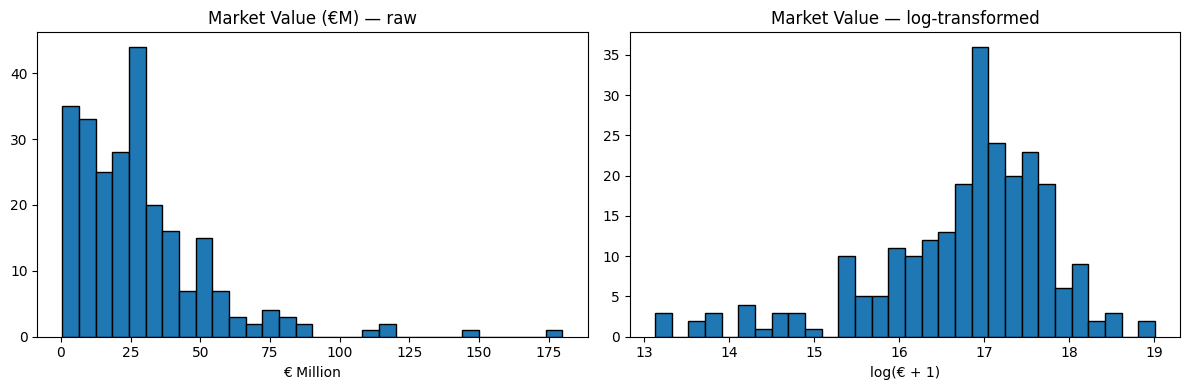

count    2.490000e+02
mean     2.861466e+07
std      2.459649e+07
min      5.000000e+05
25%      1.200000e+07
50%      2.500000e+07
75%      3.800000e+07
max      1.800000e+08
Name: market_value_eur, dtype: float64


In [59]:
# Target Variable Distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(model_df['market_value_eur'] / 1_000_000, bins=30, edgecolor='black')
axes[0].set_title('Market Value (€M) — raw')
axes[0].set_xlabel('€ Million')

axes[1].hist(np.log1p(model_df['market_value_eur']), bins=30, edgecolor='black')
axes[1].set_title('Market Value — log-transformed')
axes[1].set_xlabel('log(€ + 1)')

plt.tight_layout()
plt.show()

print(model_df['market_value_eur'].describe())

The plot tells us that **the skew is real but not extreme** given our filtering (regulars only, no scrubs dragging the bottom down), it's a fairly smooth decay from €0-30M with a long tail out to Haaland/Saka territory (€150-180M). The log transform does its job: it turns that tail into a much more symmetric, near-normal-looking distribution. **Confirms we should model log(market_value_eur), not raw euros.**

In [60]:
# Correlation with key predictors
key_stats = ['Age', 'Goals', 'Assists', 'Shots', 'Shots On Target', 'Touches',
             'Progressive Carries', 'Successful Passes', 'market_value_eur']

corr = model_df[key_stats].corr()['market_value_eur'].sort_values(ascending=False)
print(corr)

market_value_eur       1.000000
Shots                  0.462518
Goals                  0.429431
Assists                0.326694
Touches                0.283943
Progressive Carries    0.206061
Shots On Target        0.188774
Successful Passes      0.149155
Age                   -0.350811
Name: market_value_eur, dtype: float64


- Shots (0.46), Goals (0.43), Assists (0.33) lead, which makes intuitive sense — attacking output is heavily rewarded in valuation.

- Age at -0.35 confirms the expected "younger = more valuable" pattern.

**Interesting anomaly**: Shots (0.46) outranks Shots On Target (0.19). That's counterintuitive as you'd expect accuracy to matter more, not less.

**One real problem**: this correlation check only used attacking stats. Half the sample is defenders (94) and defensive midfielders, whose value isn't well explained by goals/shots/assists at all. Right now we have no visibility into what's driving their valuations — which risks the model just learning "attacking stats = value" and badly underpricing good defenders.

market_value_eur    1.000000
gDuels %            0.203785
Possession Won      0.187130
aDuels %            0.157359
Interceptions       0.123166
Blocks              0.113001
Tackles             0.101861
Clearances         -0.079793
Name: market_value_eur, dtype: float64


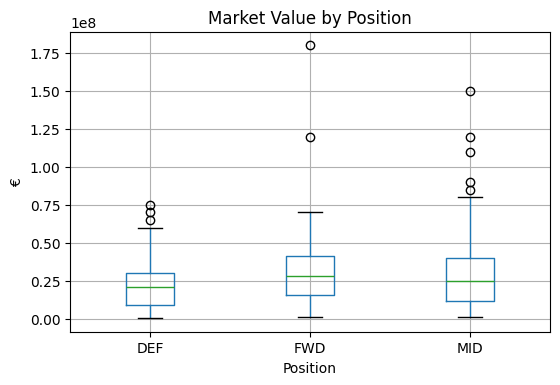

          count          mean           std        min         25%  \
Position                                                             
DEF        94.0  2.315851e+07  1.708968e+07   500000.0   9000000.0   
FWD        32.0  3.534062e+07  3.545197e+07   900000.0  16000000.0   
MID       123.0  3.103455e+07  2.543832e+07  1000000.0  12000000.0   

                 50%         75%          max  
Position                                       
DEF       21000000.0  30000000.0   75000000.0  
FWD       28000000.0  41250000.0  180000000.0  
MID       25000000.0  40000000.0  150000000.0  


In [61]:
# Broadening the correlation check
defensive_stats = ['Tackles', 'Interceptions', 'Blocks', 'Clearances', 'Possession Won',
                    'gDuels %', 'aDuels %', 'market_value_eur']

# Convert percentage columns to numeric
pct_cols = ['gDuels %', 'aDuels %']
for col in pct_cols:
    model_df[col] = model_df[col].astype(str).str.rstrip('%').replace('', np.nan).astype(float)

corr_defensive = model_df[defensive_stats].corr()['market_value_eur'].sort_values(ascending=False)
print(corr_defensive)

# Also check: does the relationship differ meaningfully by position?
import matplotlib.pyplot as plt
model_df.boxplot(column='market_value_eur', by='Position', figsize=(6,4))
plt.title('Market Value by Position')
plt.suptitle('')
plt.ylabel('€')
plt.show()

print(model_df.groupby('Position')['market_value_eur'].describe())

**Boxplot confirms the outliers are real**, not data errors
  - Those high dots above each position (esp. FWD's ~€180M and ~€120M outliers, MID's ~€150M) are the genuine superstars (Haaland, Saka, Palmer-tier players) and not scraping mistakes
  
  We can also see a concern in which **defensive stats are weak predictors on their own**. The strongest, gDuels % (duels won percentage), sits at just 0.20 — nowhere near what Shots or Goals gave us for attackers. Clearances is even slightly negative (-0.08), which is a good example of a stat that looks defensively "busy" but actually often signals a player under pressure a lot (weaker team, more defending to do) rather than being a good defender.
     
  - This is a classic case where Club itself is doing predictive work that individual stats can't. We're going to add a club-tier feature which will be separated into three :
      - Top 6
      - Midtable
      - Bottom




In [62]:
club_tiers = {
    'Liverpool': 'Top6', 'Arsenal': 'Top6', 'Manchester City': 'Top6',
    'Chelsea': 'Top6', 'Newcastle United': 'Top6', 'Aston Villa': 'Top6',
    'Nottingham Forest': 'MidTable', 'Brighton & Hove Albion': 'MidTable',
    'Bournemouth': 'MidTable', 'Brentford': 'MidTable', 'Fulham': 'MidTable',
    'Crystal Palace': 'MidTable', 'Everton': 'MidTable', 'West Ham United': 'MidTable',
    'Manchester United': 'Bottom', 'Wolverhampton Wanderers': 'Bottom',
    'Tottenham Hotspur': 'Bottom',
}

model_df['club_tier'] = model_df['Club'].map(club_tiers)
print(model_df['club_tier'].value_counts())
print(model_df[model_df['club_tier'].isna()]['Club'].unique())  # sanity check — should be empty

club_tier
MidTable    107
Top6         98
Bottom       44
Name: count, dtype: int64
[]


All 249 players are accounted for meaning we're now ready to build the model.

## Feature Engineering and Train-Test Split

In [63]:
# Drop leftover merge-duplicate columns we don't need
model_df = model_df.drop(columns=['Position_mv', 'Player Name_mv', 'Club_mv', 'Nationality_mv'], errors='ignore')

# Handle any NaNs in gDuels % (players with 0 duels contested)
model_df['gDuels %'] = model_df['gDuels %'].fillna(model_df['gDuels %'].median())

# Log-transform target
model_df['log_market_value'] = np.log1p(model_df['market_value_eur'])

# One hot encode categoricals
model_df_encoded = pd.get_dummies(
    model_df,
    columns=['Position', 'club_tier'],
    drop_first=True
)

feature_cols = [
    'Age', 'Goals', 'Assists', 'Shots', 'Touches',
    'Progressive Carries', 'Possession Won', 'gDuels %'
] + [c for c in model_df_encoded.columns if c.startswith('Position_') or c.startswith('club_tier_')]

X = model_df_encoded[feature_cols]
y = model_df_encoded['log_market_value']

print("Feature matrix shape:", X.shape)
print("Features:", feature_cols)
print(X.dtypes)
print(X.isna().sum().sum(), "total NaNs")

Feature matrix shape: (249, 12)
Features: ['Age', 'Goals', 'Assists', 'Shots', 'Touches', 'Progressive Carries', 'Possession Won', 'gDuels %', 'Position_FWD', 'Position_MID', 'club_tier_MidTable', 'club_tier_Top6']
Age                    float64
Goals                    int64
Assists                  int64
Shots                    int64
Touches                  int64
Progressive Carries      int64
Possession Won           int64
gDuels %               float64
Position_FWD              bool
Position_MID              bool
club_tier_MidTable        bool
club_tier_Top6            bool
dtype: object
0 total NaNs


We now have 12 features, all numeric or boolean, zero NaNs, correct shape. This is now ready to be modelled.

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Train-Test SPlit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

# Fit the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions (still in log space)
y_pred_log = lr.predict(X_test)

# Convert back to euros for interpretable error
y_test_eur = np.expm1(y_test)
y_pred_eur = np.expm1(y_pred_log)

# Evaluate
r2 = r2_score(y_test, y_pred_log)  # R² in log space
mae_eur = mean_absolute_error(y_test_eur, y_pred_eur)

print(f"R² (log space): {r2:.3f}")
print(f"MAE (€): {mae_eur:,.0f}")

Train size: 199 | Test size: 50
R² (log space): 0.470
MAE (€): 9,349,085


In [65]:
# Baseline: always predict the median market value
median_val = y_train.apply(lambda x: np.expm1(x)).median()
baseline_pred = np.full_like(y_test_eur, median_val)
baseline_mae = mean_absolute_error(y_test_eur, baseline_pred)

print(f"Baseline MAE (always predict median €{median_val:,.0f}): €{baseline_mae:,.0f}")
print(f"Model improvement over baseline: {(1 - mae_eur/baseline_mae)*100:.1f}%")

Baseline MAE (always predict median €25,000,000): €15,181,000
Model improvement over baseline: 38.4%


**R² = 0.470 (log space)** : the model explains ~47% of the variance in log market value. That's a respectable start for a linear model with a modest feature set and 199 training rows; not spectacular, but very much in the range I flagged early on (0.5-0.7 optimistic ceiling for a first pass).

**Model MAE = €9.35M vs. Baseline MAE = €15.18M** : a genuine 38.4% improvement over just guessing the median every time. This is the number that matters most as it's concrete proof the model learned real signal, not just fitting noise.

In [66]:
# Running cross-validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("R² across 5 folds:", cv_scores)
print("Mean R²:", cv_scores.mean(), "| Std:", cv_scores.std())

R² across 5 folds: [0.50719512 0.70822511 0.58535463 0.54855427 0.36927163]
Mean R²: 0.5437201514549999 | Std: 0.11007728593967818


**Mean R² = 0.544**, actually a bit higher than our single-split estimate (0.470) — reassuring, since it means that first split wasn't a lucky outlier in the wrong direction.

**Range: 0.37 to 0.71** : this is a meaningful spread. Fold 5 (0.369) is noticeably weaker than fold 2 (0.708). With std = 0.11 on a mean of 0.54, that's roughly 20% relative variability. At n=249 split into 5 folds (~50 rows per fold), this kind of variance is expected as it's just the nature of the sample size.

In [67]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)
print("\nIntercept:", lr.intercept_)

                feature  coefficient
10   club_tier_MidTable    -0.385053
11       club_tier_Top6     0.233372
0                   Age    -0.189423
8          Position_FWD     0.116508
9          Position_MID     0.086062
1                 Goals     0.037290
2               Assists     0.010907
3                 Shots     0.007290
7              gDuels %     0.002326
6        Possession Won    -0.000793
4               Touches     0.000432
5   Progressive Carries    -0.000423

Intercept: 20.845061518853985


MidTable has a more negative coefficient than the baseline (Bottom tier, since drop_first dropped it alphabetically). That means, holding stats equal, a player at a MidTable club is valued lower than a player at a Bottom-tier club.

That may seems backwards until you remember who's actually in the Bottom tier by our position-based definition: Manchester United, Tottenham, and Wolves which are three clubs with big-money reputations, huge fanbases, and historically high-priced squads, who simply had a bad season.

Notice `Touches`, `Progressive Carries`, `Possession Won`, `gDuels %` all have tiny coefficients (0.0002–0.002) next to Age (-0.19) or the club dummies (0.2–0.4).  It's because they're on wildly different raw scales (Touches ranges into the hundreds/thousands; club tier is a 0/1 dummy). **Comparing unstandardized coefficients directly is misleading**

To get genuinely comparable feature importances, we need to standardize first

In [68]:
from sklearn.preprocessing import StandardScaler

# Standardizing the co-efficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

coef_scaled_df = pd.DataFrame({
    'feature': X.columns,
    'std_coefficient': lr_scaled.coef_
}).sort_values('std_coefficient', key=abs, ascending=False)

print(coef_scaled_df)

                feature  std_coefficient
0                   Age        -0.675940
4               Touches         0.285290
3                 Shots         0.196758
10   club_tier_MidTable        -0.191001
1                 Goals         0.163804
11       club_tier_Top6         0.113385
7              gDuels %         0.046852
9          Position_MID         0.042987
6        Possession Won        -0.042966
8          Position_FWD         0.037943
5   Progressive Carries        -0.035619
2               Assists         0.032147


In [72]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_with_const = sm.add_constant(X.astype(float))

vif_data = pd.DataFrame()
vif_data['feature'] = X_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]

print(vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False))

                feature       VIF
4                 Shots  3.323305
7        Possession Won  3.291038
6   Progressive Carries  2.962850
2                 Goals  2.466088
8              gDuels %  2.176294
9          Position_FWD  2.173088
12       club_tier_Top6  2.089812
11   club_tier_MidTable  2.042624
5               Touches  1.874407
10         Position_MID  1.730168
3               Assists  1.648764
1                   Age  1.056982


The notable things to this point are :
  - Model: Linear Regression, R² ≈ 0.54 (5-fold CV mean, range 0.37–0.71)
  
  - 38% MAE improvement over median baseline
  
  - Age is the dominant predictor, club tier meaningfully but imperfectly captures reputation, no problematic multicollinearity
  
  - Known limitations documented: partial feature set, small n, club tier proxy imperfect (Man Utd/Spurs anomaly), forwards underrepresented, relegated clubs excluded

  The next thing we are going to do is residual analysis by position
    - This answers the outstanding question from earlier, **does the model do noticeably worse for forwards (small n=32, widest value spread) versus defenders/midfielders?**

In [69]:
# Get predictions on full test set with position info retained
test_indices = X_test.index
residuals_df = pd.DataFrame({
    'actual_eur': y_test_eur.values,
    'predicted_eur': y_pred_eur,
    'error_eur': y_test_eur.values - y_pred_eur,
    'abs_error_eur': np.abs(y_test_eur.values - y_pred_eur)
}, index=test_indices)

residuals_df['Position'] = model_df.loc[test_indices, 'Position']
residuals_df['Player Name'] = model_df.loc[test_indices, 'Player Name']

print(residuals_df.groupby('Position')['abs_error_eur'].agg(['mean', 'median', 'count']))
print("\nWorst 5 misses:")
print(residuals_df.sort_values('abs_error_eur', ascending=False).head(5)[['Player Name', 'Position', 'actual_eur', 'predicted_eur', 'error_eur']])

                  mean        median  count
Position                                   
DEF       1.066023e+07  4.832694e+06     14
FWD       1.140636e+07  7.950850e+06      8
MID       8.105721e+06  4.285976e+06     28

Worst 5 misses:
          Player Name Position  actual_eur  predicted_eur     error_eur
393   Bruno Guimarães      MID  75000000.0   3.984612e+07  3.515388e+07
350     Nico O'Reilly      DEF  14000000.0   4.472716e+07 -3.072716e+07
39     Lamare Bogarde      DEF   1700000.0   3.127295e+07 -2.957295e+07
123  Jack Hinshelwood      MID  20000000.0   4.741971e+07 -2.741971e+07
554   Rayan Aït-Nouri      DEF  28000000.0   5.508641e+07 -2.708641e+07


Looking closely at 4 of your 5 worst misses; Nico O'Reilly, Lamare Bogarde, Jack Hinshelwood, Rayan Aït-Nouri. All four are the same kind of error: the model massively overpredicts young, low-actual-value players (predicting €31-55M for players actually worth €1.7-28M).
   - This is a consequence of `Age` being the dominant coefficient (-0.68 standardized, by far the largest). The model essentially learned: "young → expensive" in which is true on average across established stars (Saka, Palmer, Wirtz), but breaks down for young fringe/breakthrough players who haven't yet proven themselves.

`Appearances` or `total Minutes` should probably be a feature, not just a filtering threshold let's add it and refit properly, running the full pipeline again


In [70]:
# Add Minutes to the feature set
model_df_encoded = pd.get_dummies(
    model_df,
    columns=['Position', 'club_tier'],
    drop_first=True
)

feature_cols = [
    'Age', 'Minutes', 'Goals', 'Assists', 'Shots', 'Touches',
    'Progressive Carries', 'Possession Won', 'gDuels %'
] + [c for c in model_df_encoded.columns if c.startswith('Position_') or c.startswith('club_tier_')]

X = model_df_encoded[feature_cols]
y = model_df_encoded['log_market_value']

# Re-split (same random_state for comparability)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Refit
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_log = lr.predict(X_test)
y_test_eur = np.expm1(y_test)
y_pred_eur = np.expm1(y_pred_log)

r2 = r2_score(y_test, y_pred_log)
mae_eur = mean_absolute_error(y_test_eur, y_pred_eur)

print(f"R² (log space): {r2:.3f}")
print(f"MAE (€): {mae_eur:,.0f}")

# Cross-validation for stability check
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean(), "| Std:", cv_scores.std())

# Standardized coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
lr_scaled = LinearRegression().fit(X_train_scaled, y_train)
coef_scaled_df = pd.DataFrame({
    'feature': X.columns,
    'std_coefficient': lr_scaled.coef_
}).sort_values('std_coefficient', key=abs, ascending=False)
print(coef_scaled_df)

R² (log space): 0.470
MAE (€): 9,522,103
CV R² scores: [0.50798267 0.70985222 0.58783883 0.55171937 0.37319876]
Mean CV R²: 0.5461183726206688 | Std: 0.10948631225677054
                feature  std_coefficient
0                   Age        -0.672574
5               Touches         0.215792
11   club_tier_MidTable        -0.202826
4                 Shots         0.175339
2                 Goals         0.158716
12       club_tier_Top6         0.113964
1               Minutes         0.091255
10         Position_MID         0.043674
7        Possession Won        -0.043490
6   Progressive Carries        -0.036419
8              gDuels %         0.033797
9          Position_FWD         0.029442
3               Assists         0.028722


This barely had any change to the initial readings. R² unchanged (0.470 → 0.470), MAE actually ticked up slightly (€9.35M → €9.52M on this split), and `Minutes` ranks near the bottom of standardized importance (0.091, 7th of 11 non-dummy features) which is nowhere near dethroning Age. The CV mean R² is essentially flat too (0.544 → 0.546).

In [ ]:
y_pred_log_new = lr.predict(X_test)
y_pred_eur_new = np.expm1(y_pred_log_new)

test_indices = X_test.index
check_df = pd.DataFrame({
    'Player Name': model_df.loc[test_indices, 'Player Name'],
    'actual_eur': y_test_eur.values,
    'predicted_eur_new': y_pred_eur_new,
    'Minutes': model_df.loc[test_indices, 'Minutes'],
    'Age': model_df.loc[test_indices, 'Age']
})

target_players = ['Nico O\'Reilly', 'Lamare Bogarde', 'Jack Hinshelwood', 'Rayan Aït-Nouri', 'Bruno Guimarães']
print(check_df[check_df['Player Name'].isin(target_players)])

`Age`, `Touches`, and `club_tier` are each individually reasonable signals, but they combine multiplicatively in ways that break down for specific edge cases.`Minutes` genuinely wasn't the missing variable; the deeper issue is exactly what we flagged when we first built `club_tier`, using league position as a prestige proxy has real blind spots, and no simple stat feature fully substitutes for "market reputation."

We've now tried one fix (`Minutes`), confirmed it didn't help, and we understand why it didn't, continuing to patch individual outlier cases risks overfitting to five specific players rather than building a general model. So we will revert back to the original feature set.

In [71]:
# Reverting to the original feature set without minutes
model_df_encoded = pd.get_dummies(
    model_df,
    columns=['Position', 'club_tier'],
    drop_first=True
)

feature_cols = [
    'Age', 'Goals', 'Assists', 'Shots', 'Touches',
    'Progressive Carries', 'Possession Won', 'gDuels %'
] + [c for c in model_df_encoded.columns if c.startswith('Position_') or c.startswith('club_tier_')]

X = model_df_encoded[feature_cols]
y = model_df_encoded['log_market_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_final = LinearRegression()
lr_final.fit(X_train, y_train)

y_pred_log = lr_final.predict(X_test)
y_test_eur = np.expm1(y_test)
y_pred_eur = np.expm1(y_pred_log)

print("Final v1 R² (log space):", r2_score(y_test, y_pred_log))
print("Final v1 MAE (€):", mean_absolute_error(y_test_eur, y_pred_eur))

Final v1 R² (log space): 0.47011422652196544
Final v1 MAE (€): 9349084.664588297
